In [1]:
# =======================
# Standard library
# =======================
import os
import math
import random
from collections import defaultdict
from types import SimpleNamespace

# =======================
# Scientific stack
# =======================
import numpy as np
import pandas as pd
import networkx as nx
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from skimage.measure import label

# =======================
# Geospatial stack
# =======================
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from rasterio.transform import from_origin

import osmnx as ox
from pyproj import CRS, Transformer

from shapely.errors import TopologicalError
from shapely.geometry import (
    Point,
    LineString,
    MultiLineString,
    Polygon,
    MultiPolygon,
    box,
)
from shapely.ops import unary_union, linemerge
from shapely.strtree import STRtree

# Shapely version compatibility (make_valid exists in Shapely ≥ 2.0)
try:
    from shapely.validation import make_valid
except Exception:
    make_valid = None

# =======================
# Plotting
# =======================
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import LightSource

# =======================
# Time-series / NetCDF
# =======================
import xarray as xr

import sys
from pathlib import Path

SEWERTRIS_DIR = Path("..") / "Functions"   # adjust if needed
sys.path.append(str(SEWERTRIS_DIR))

# =======================
# SewerTris modules (your split files)
# =======================
import sewertris_fn_0_1 as SewerTris
import sewertris_plots_0_1 as plots
import sewertris_swmm_0_1 as swmm

# =======================
# Optional: reload during development
# =======================
import importlib
importlib.reload(SewerTris)
importlib.reload(plots)
importlib.reload(swmm)

<module 'sewertris_swmm_0_1' from '/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_swmm_0_1.py'>

## 1. Domain Mask

You can choose to define the domain mask manually (as before) or generate it automatically from a basin shapefile. The shapefile must be in WGS84. The minimum width of a Tetris element (in meters) is set by `min_width` (default: 60 m).

In [2]:
# --- Parameters ---
min_width = 100  # meters
use_shapefile = True  # Set to False to use manual domain_mask
shapefile_path = "input/domain_mask.shp"

In [3]:
if use_shapefile:
    gdf_in = gpd.read_file(shapefile_path)
    cell_size = SewerTris.meters_to_crs_units(min_width, gdf_in.crs)  # converts meters -> feet if needed
    domain_mask, grid_meta = SewerTris.build_domain_mask_from_shapefile(shapefile_path, cell_size_m=cell_size)
else:
    domain_mask = np.array([
        [0,0,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
    ])
    grid_meta = dict(crs_out="EPSG:3857", origin_x=0, origin_y=0, cell_w=min_width, cell_h=min_width, rows=domain_mask.shape[0], cols=domain_mask.shape[1])



## 2. Define Tetris Tetrominoes and Their Rotations

Each tetromino is defined as a set of 2D numpy arrays, one for each rotation.

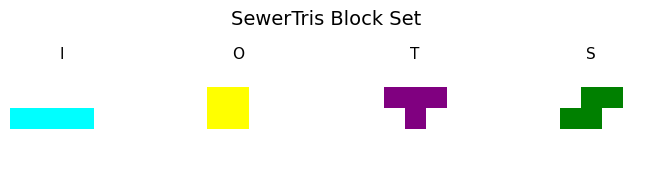

In [4]:
# Tetromino definitions (all rotations)
tetrominoes = {
    'I': [np.array([[1,1,1,1]]), np.array([[1],[1],[1],[1]])],
    'O': [np.array([[1,1],[1,1]])],
    'T': [np.array([[1,1,1],[0,1,0]]), np.array([[0,1],[1,1],[0,1]]), np.array([[0,1,0],[1,1,1]]), np.array([[1,0],[1,1],[1,0]])],
    'S': [np.array([[0,1,1],[1,1,0]]), np.array([[1,0],[1,1],[0,1]])],
}

# Assign a color to each tetromino
tetromino_colors = {
    'I': 'cyan',
    'O': 'yellow',
    'T': 'purple',
    'S': 'green',
}

plots.plot_tetromino_set(tetrominoes, tetromino_colors, ncols=4)

## 3. Tetris Domain Filling Algorithm

This function attempts to fill the domain with random tetrominoes, without overlap and only within the mask. It tries a fixed number of random placements for each empty cell.

In [5]:
filled_board, id_type_map, _ = SewerTris.fill_domain_with_tetrominoes_and_blocks(domain_mask, tetrominoes)
print("Total blocks:", len(np.unique(filled_board)))

Total blocks: 1647


## 4. Export to Shapefile

Each block becomes a polygon.

✅ Exported 1646 figures to output_sewertris_3/City_3.shp


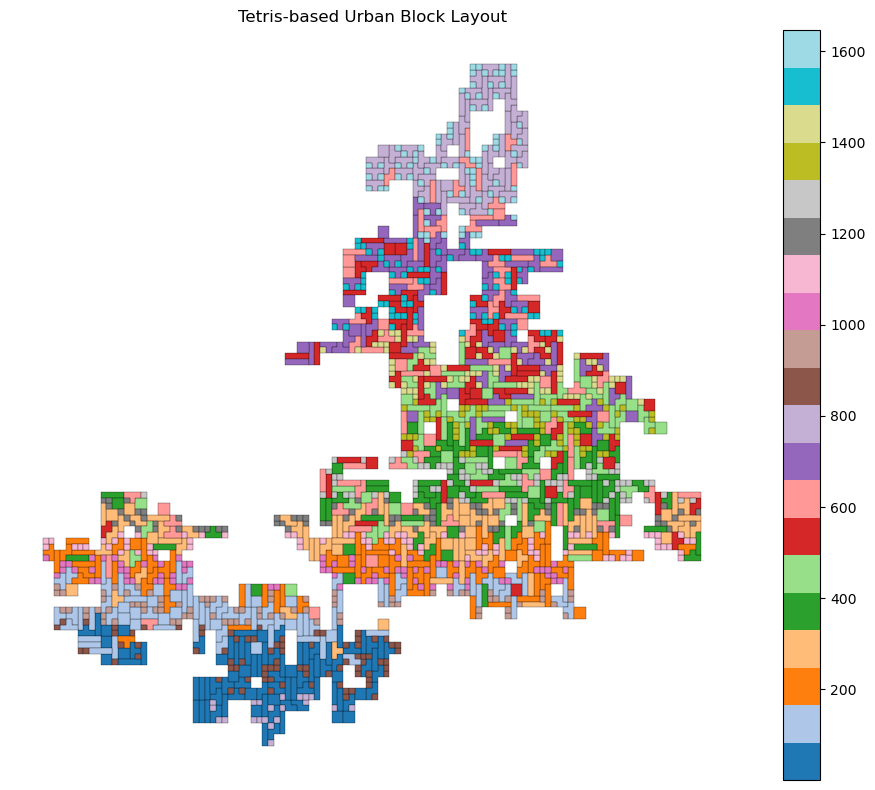

In [6]:
# Export the filled board to a shapefile
output_folder = "output_sewertris_3"
os.makedirs(output_folder, exist_ok=True)  # Create if it doesn't exist
output_shapefile = os.path.join(output_folder, "City_3.shp")

# Export in same CRS + same coordinate space as original shapefile
SewerTris.export_individual_figures_to_shapefile_georeferenced(
    filled_board,
    output_shapefile,
    grid_meta,
    id_to_type_map=id_type_map
)

plots.plot_filled_board_shapefile(output_shapefile)

## 5. Road Network

Set the road network using the blocks borders.

In [7]:
road_width = 10  # Width of the road in meters
road_lines, road_buffer, crs = SewerTris.generate_road_network_from_blocks(
    blocks_path=output_shapefile,
    road_width=road_width,          # road width in meters
    simplify_tol=0.5       # optional geometry simplification
)
gpd.GeoDataFrame(geometry=[road_lines], crs=crs).to_file(os.path.join(output_folder,"road_centerlines.shp"))
gpd.GeoDataFrame(geometry=[road_buffer], crs=crs).to_file(os.path.join(output_folder,"road_polygons.shp"))

## 6. Topography

Set the direction, the min and max elevation to generates the dem

[OK] Boundary lines written to: output_sewertris_3/road_boundary_lines.shp
[OK] Outer shell polygon(s) written to: output_sewertris_3/road_outer_shell.shp
Original boundary CRS: EPSG:32614
Original roads CRS: EPSG:32614

Boundary extent:
X range: 667166.00 to 678576.00
Y range: 3994829.67 to 4006639.67
Boundary CRS: EPSG:32614
Boundary bounds: [ 667165.9958307  3994829.67323194  678575.9958307  4006639.67323194]
Grid shape: (1202, 1162)
Grid extent:
  X: 667060.00 to 678680.00
  Y: 3994720.00 to 4006740.00
Creating mask...
Processing row 0 of 1202
Processing row 100 of 1202
Processing row 200 of 1202
Processing row 300 of 1202
Processing row 400 of 1202
Processing row 500 of 1202
Processing row 600 of 1202
Processing row 700 of 1202
Processing row 800 of 1202
Processing row 900 of 1202
Processing row 1000 of 1202
Processing row 1100 of 1202
Processing row 1200 of 1202
Outlet cell: (1110, 591)
Computing geodesic distances...
Processing roads...


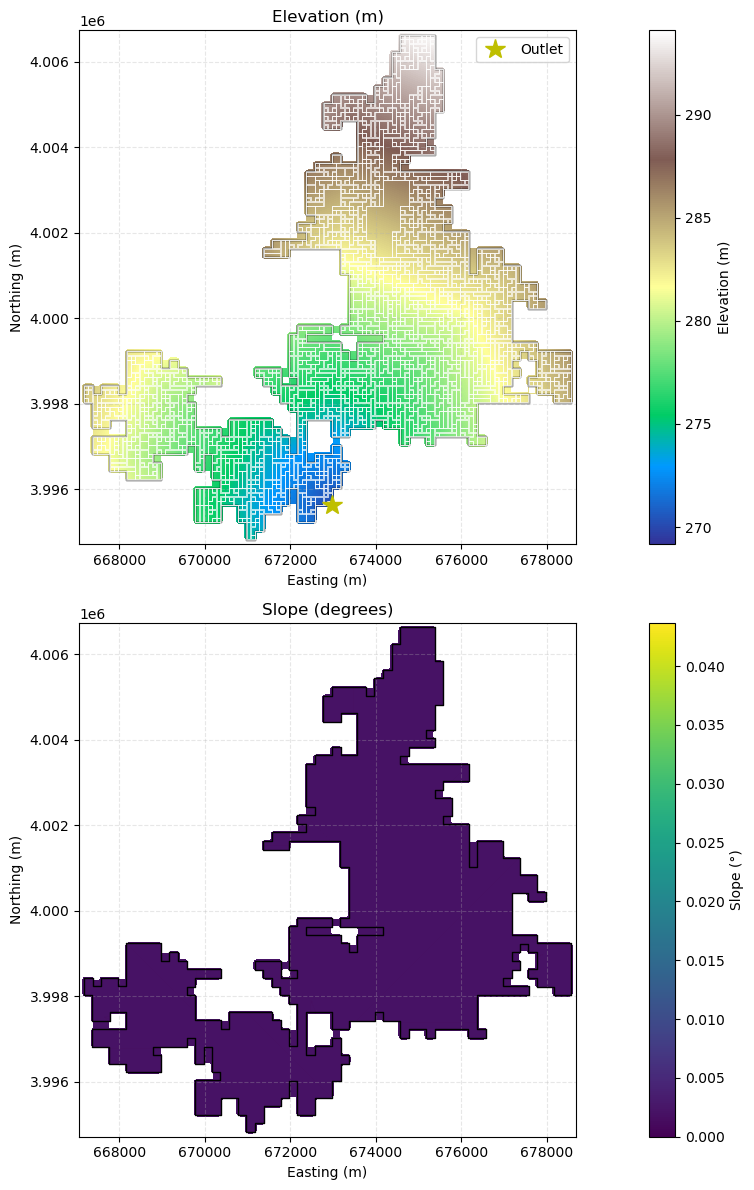


Terrain Statistics:
Elevation range: 269.17m - 294.09m
Mean elevation: 281.10m
Mean slope: 0.00°
Max slope: 0.04°

Drainage Statistics:
Points with proper drainage: 500309.0 out of 533617 (93.8%)
Using CRS: EPSG:32614
Topography successfully generated and saved to output_sewertris_3/generated_topography.tif
DEM resolution: 10m
Elevation range: 270m - 290m
Output CRS: EPSG:32614
Grid extent: 
  X: 667060.00 to 678680.00
  Y: 4006740.00 to 3994720.00


In [8]:
roads_path = os.path.join(output_folder,"road_polygons.shp")
SewerTris.extract_boundary(
    roads_path,
    out_boundary_lines=os.path.join(output_folder,"road_boundary_lines.shp"),          # lines (outer +/- holes)
    out_outer_shell_polygon=os.path.join(output_folder,"road_outer_shell.shp"),        # polygon(s) with holes removed
    keep_holes=False                                       # only outer rings in the line output
)


config = SewerTris.TopographyConfig(
    min_elevation=270,    # meters
    max_elevation=290,    # meters
    cell_size=10,         # meters - reduced for better resolution
    outlet_direction='S', # North (N), South (S), East (E), or West (W)
    smoothing_factor=1  # Reduced for sharper drainage patterns
)

# File paths for Stillwater data
boundary_path = os.path.join(output_folder,"road_outer_shell.shp")
roads_path = os.path.join(output_folder,"road_polygons.shp")

# Ensure input files exist
if not os.path.exists(boundary_path) or not os.path.exists(roads_path):
    raise FileNotFoundError("Input shapefiles not found. Please check the file paths.")

try:
    # Generate topography
    elevation, xx, yy, mask = SewerTris.generate_topography(boundary_path, roads_path, config)
    
    # Get the CRS from the input data
    boundary_gdf = gpd.read_file(boundary_path)
    input_crs = boundary_gdf.crs
    
    if input_crs is None:
        print("Warning: Input CRS is None, defaulting to UTM Zone 14N (EPSG:32614)")
        input_crs = "EPSG:32614"  # UTM Zone 14N (appropriate for Stillwater, OK)
    
    print(f"Using CRS: {input_crs}")
    
    # Save the resulting DEM as a GeoTIFF
    output_path = os.path.join(output_folder, "generated_topography.tif")
    
    # Create the proper transform
    transform = rasterio.transform.from_bounds(
        west=xx[0,0],    # leftmost coordinate
        south=yy[-1,0],  # bottom coordinate
        east=xx[0,-1],   # rightmost coordinate
        north=yy[0,0],   # top coordinate
        width=elevation.shape[1],
        height=elevation.shape[0]
    )
    
    # Save with the same CRS as input data
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=elevation.shape[0],
        width=elevation.shape[1],
        count=1,
        dtype=elevation.dtype,
        crs=input_crs,
        transform=transform,
        nodata=np.nan
    ) as dst:
        # Write the data ensuring proper orientation
        dst.write(elevation, 1)
    
    print(f"Topography successfully generated and saved to {output_path}")
    print(f"DEM resolution: {config.cell_size}m")
    print(f"Elevation range: {config.min_elevation}m - {config.max_elevation}m")
    print(f"Output CRS: {input_crs}")
    print(f"Grid extent: ")
    print(f"  X: {xx[0,0]:.2f} to {xx[0,-1]:.2f}")
    print(f"  Y: {yy[0,0]:.2f} to {yy[-1,0]:.2f}")
    
except Exception as e:
    print(f"Error generating topography: {str(e)}")
    raise

## 7. Assing Land Use

Set land use for each block

In [9]:
blocks_path = output_shapefile
roads_path = os.path.join(output_folder,"road_polygons.shp")
output_path = os.path.join(output_folder,"City_3.shp")

blocks, road_network, crs = SewerTris.load_blocks_and_roads(blocks_path, roads_path)
blocks = SewerTris.cut_blocks(blocks, road_network)
blocks = SewerTris.assign_land_use_compact(blocks)
gdf = SewerTris.export_to_shapefile(blocks, crs, output_path)

✅ Exported to output_sewertris_3/City_3.shp


## 8. Generates Sewer Path

Base on the road netwoek and topography generates the sewer path.

In [10]:
road_axes_path=os.path.join(output_folder,"road_centerlines.shp")
dem_path=os.path.join(output_folder,"generated_topography.tif")
manholes = SewerTris.extract_manholes_from_lines(road_axes_path, dem_path)
SewerTris.export_manholes_to_shapefile(manholes, os.path.join(output_folder,"manholes.shp"), crs=gpd.read_file(road_axes_path).crs)
# Generate main sewer path
main_path, path_info = SewerTris.generate_main_sewer_path(
    manholes=manholes,
    road_buffer=road_lines.buffer(road_width * 0.6),
    block_size=min_width*2,
    slope_tolerance=-0.05,
    min_pipe_length=5.0,
    prefer_slope=0.6,
)

#Generate secondary sewer pipes
secondary_pipes = SewerTris.generate_secondary_pipes(
    manholes=manholes,
    main_path=main_path,
    road_buffer=road_lines.buffer(road_width * 0.6),  # already computed,
    block_size=min_width * 2,
    slope_tolerance=0.00  # allow only downhill connections
)

# Then clean overlapping ones
secondary_pipes_clean = SewerTris.remove_secondary_pipes_overlapping_main(
    manholes=manholes,
    secondary_pipes=secondary_pipes,
    main_pipes=main_path
)

# Step 1: Load the shapefile
roads_gdf = gpd.read_file(roads_path)  # roads_path is a string

# Step 2: Create a unified geometry from all polygons/multipolygons
road_buffer = unary_union(roads_gdf.geometry)

# Generate tertiary sewer pipes
tertiary_pipes, unresolved = SewerTris.generate_tertiary_pipes(
    manholes=manholes,
    main_path=main_path,  # ← corrected from main_pipes
    secondary_pipes=secondary_pipes_clean,
    road_buffer=road_buffer,
    block_size=min_width * 2,
)

# Export all pipes to a single shapefile
SewerTris.export_pipes_to_shapefile(
    pipes_main=main_path,
    pipes_sec=secondary_pipes_clean,
    pipes_ter=tertiary_pipes,
    manholes=manholes,
    output_path=os.path.join(output_folder,"sewer_pipes.shp"),
    crs=crs  # UTM Zone 18N, or use "EPSG:4326" for lat/lon
)

print("✓ Sewer network generation complete.")

✅ Extracted 3600 manholes from road centerlines.
✅ Manholes exported to output_sewertris_3/manholes.shp

Path Statistics:
Head: MH1955  →  Target: MH2248
Segments: 127
Total length: 15600.0 m
Total drop: 24.82 m
Avg slope: 0.089%
⚠️ Some manholes couldn’t be connected while preserving constraints.
✅ Generated 1340 secondary pipes (tree structure preserved).
✅ Cleaned: 0 secondary pipes removed.
✅ Tertiary pipes generated (raw): 2756
🧹 Tertiary pipes removed to prevent cycles: 122
🚫 Tertiary pipes removed due to multiple outlet conflicts: 38
🌳 Final tree-safe tertiary pipes: 2132
✅ Exported 3599 pipes to: output_sewertris_3/sewer_pipes.shp with CRS: EPSG:32614
✓ Sewer network generation complete.


/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:1672: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstream'
  ogr_write(


## 9. Modifying Topography to Follow Sewer Network

We'll now modify the terrain to ensure proper drainage along the sewer network. This process:
1. Adjusts elevations along pipe paths
2. Creates smooth transitions to surrounding terrain
3. Ensures consistent downhill flow
4. Preserves overall drainage patterns

In [11]:

print("Modifying topography to follow sewer network...")

# Define paths and parameters
dem_path = os.path.join(output_folder, "generated_topography.tif")
sewer_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
output_path = os.path.join(output_folder, "generated_topography.tif")

out_path = SewerTris.build_dem_with_guaranteed_positive_slopes_idw(
    dem_path=dem_path,
    pipes_path=sewer_path,
    manholes_path=manholes_path,
    output_path=output_path,
    upstream_field="upstream_m",
    downstream_field="downstream",
    manhole_id_field="id",
    manhole_elev_field="elevation",
    type_field="type",
    tier_order=("main","secondary","tertiary"),
    Smin=0.001,                                 # 0.3% min slope
    densify_step_m=None,                        # default ≈ 2 pixels
    along_pipe_weight=2,                        # small bias toward pipes
    idw_power=2.0, idw_k=12, idw_tile=1024,
    centerline_writeback=True,                  # guarantees pixel-level monotone on centerlines
    verify_on_raster=True
)
print("Wrote:", out_path)

Modifying topography to follow sewer network...
⚠️ Raster check: 3120 pipes have a local slope < Smin (e.g., idx=449, slope=-0.000069).
Wrote: output_sewertris_3/generated_topography.tif


## 10. Update Manhole Elevations

In [12]:
SewerTris.update_manhole_elevations_from_dem(
    dem_path=out_path,
    manholes_path=manholes_path,
    output_path=None,    # None + overwrite=True -> overwrite original file
    overwrite=True,
    sampling="nearest",
)

Updated elevations for 3600/3600 manholes. Wrote: output_sewertris_3/manholes.shp


'output_sewertris_3/manholes.shp'

## 11. Sanitary Sewer Design

In [14]:
blocks_path = os.path.join(output_folder, "City_3.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
topography_path = os.path.join(output_folder, "generated_topography.tif")

#🚰 LAND_USE_INFO
# For each land use category:
# - 'density' is in people per hectare [people/ha]
# - 'demand' is in liters per person per day [L/person/day]

LAND_USE_INFO = {
    'RESIDENTIAL': {
        'density': 60,     # [people/ha]
        'demand': 100       # [L/person/day]
    },
    'COMMERCIAL': {
        'density': 50,      # [people/ha] or equivalent occupancy
        'demand': 60       # [L/person/day]
    },
    'INDUSTRIAL': {
        'density': 25,      # [people/ha] or equivalent worker density
        'demand': 150       # [L/person/day]
    },
    'PUBLIC': {
        'density': 20,      # [people/ha]
        'demand': 100       # [L/person/day]
    },
    'RECREATIONAL': {
        'density': 10,      # [people/ha]
        'demand': 40        # [L/person/day]
    }
}

# Afferent areas and baseflow

SewerTris.delineate_afferent_areas_and_baseflow(
    blocks_path=blocks_path,
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    topo_path=topography_path,
    output_path=os.path.join(output_folder, "sewer_subcatchments.shp"),
    land_use_info=LAND_USE_INFO
)

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

# Assign flow to pipes
SewerTris.assign_flow_to_pipes(
    pipes_path=pipes_path,
    subcatchments_path=subcatchments_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp")
)

# Peak flow

pipes = gpd.read_file(os.path.join(output_folder, "sewer_pipes.shp"))

# Apply BC peaking factor
peak_flow, pf = SewerTris.british_columbia_peaking_factor(pipes["cumulative"])
pipes["peaking_factor_bc"] = pf
pipes["peak_flow_lps_bc"] = peak_flow

# Save
pipes.to_file(os.path.join(output_folder, "sewer_pipes.shp"))
print("✅ Peak flows added using BC method.")

# GWI

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.compute_gwi_cumulative(
    pipes_path=pipes_path,
    gwi_factor_ls_per_m=0.0002,            # l/s per meter
    out_path=os.path.join(output_folder,"sewer_pipes.shp"),         # or None if you don't want to write
    id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    length_field=None,                     # if you already have meters in a column, put its name here
    target_crs_m="EPSG:3857"          # UTM zone for accurate length calculations
    )

# RDII

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.compute_rdii_and_accumulate(
    pipes_path=pipes_path,
    subcatch_path=subcatchments_path,
    rdii_factor_ls_per_m2=0.00002,       # L/s per m² (example)
    pipe_id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    sub_pipe_field="pipe_id",            # subcatchments' field pointing to receiving pipe
    # If your subcatchments are in degrees, choose a projected CRS in meters:
    target_crs_m="EPSG:3857",
    out_pipes=os.path.join(output_folder,"sewer_pipes.shp"),
    out_subcatch=os.path.join(output_folder,"sewer_subcatchments.shp"),
)

# Predising flow

pipes_path = os.path.join(output_folder,"sewer_pipes.shp")

SewerTris.add_predesign_flow(
    pipes_path=pipes_path,
    out_path=os.path.join(output_folder,"sewer_pipes.shp")
)

# Pipe slopes

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.assign_pipe_slopes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    minimum_slope=0.005  # Can be adjusted per local design standards
)

# Pipe Diameter and material

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.assign_material_diameter_to_pipes(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    material_fractions={"PVC": 0.6, "CONCRETE": 0.3, "HDPE": 0.1},
    n_by_material={"PVC": 0.011, "CONCRETE": 0.013, "HDPE": 0.012},
    standard_diameters_mm=[200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    minimum_diameter_mm=200
)

# Pipe Invert Elevations

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.assign_invert_elevations(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    min_cover=1.4,
    min_slope=0.005,
    manhole_drop=0.05
)

# Preprocess pipes and manholes

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.preprocess_pipes_and_manholes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_pipes_path=os.path.join(output_folder, "sewer_pipes.shp"),
    output_manholes_path=os.path.join(output_folder, "manholes.shp")
)


/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:3101: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  output.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'base_flow_lps' to 'base_flow_'
  ogr_write(


✅ Sub-catchments saved to: output_sewertris_3/sewer_subcatchments.shp


/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:3165: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'own_flow_lps' to 'own_flow_l'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'cumulative_flow_lps' to 'cumulative'
  ogr_write(
/var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/ipykernel_2371/2230225991.py:64: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(os.path.join(output_folder, "sewer_pipes.shp"))
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered 

✅ Updated pipe shapefile saved: output_sewertris_3/sewer_pipes.shp
✅ Peak flows added using BC method.


/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:3736: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'own_rdii_ls' to 'own_rdii_l'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'cum_rdii_ls' to 'cum_rdii_l'
  ogr_write(
/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:3784: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(out_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laun

✅ Pipe slopes assigned and saved to: output_sewertris_3/sewer_pipes.shp


/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:3380: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'calc_diameter_mm' to 'calc_diame'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'diameter_mm' to 'diameter_m'
  ogr_write(


✅ Materials and diameters assigned and saved to: output_sewertris_3/sewer_pipes.shp
✅ Invert elevations assigned and saved to: output_sewertris_3/sewer_pipes.shp
✅ Pipes saved to: output_sewertris_3/sewer_pipes.shp
✅ Manholes saved to: output_sewertris_3/manholes.shp


/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_fn_0_1.py:3516: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes_clean.to_file(output_pipes_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'diameter_mm' to 'diameter_1'
  ogr_write(


(     pipe_id upstream_m downstream      type  own_flow_l  cumulative  \
 0      P0000     MH1955     MH2637      main    0.017578    0.017578   
 1      P0001     MH2637     MH2096      main    0.024414    0.041992   
 2      P0002     MH2096     MH1219      main    0.031777    0.073769   
 3      P0003     MH1219      MH697      main    0.008789    0.137765   
 4      P0004      MH697     MH3594      main    0.034017    0.171782   
 ...      ...        ...        ...       ...         ...         ...   
 3594   P3594     MH2758     MH3285  tertiary    0.015644    0.015644   
 3595   P3595      MH951      MH428  tertiary    0.083073    0.158594   
 3596   P3596     MH3139     MH2424  tertiary    0.028125    0.416532   
 3597   P3597     MH1604      MH952  tertiary    0.059693    0.450535   
 3598   P3598      MH243     MH2685  tertiary    0.091811    0.206295   
 
       peaking_fa  peak_flow_  length_m  own_gwi_ls  ...  slope  slope_flag  \
 0            4.0    0.070312     100.0    

# 12. Export to EPA SWMM

In [15]:
# Export to SWMM INP format

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
options = {
    "FLOW_UNITS": "LPS",
    "INFILTRATION": "CURVE_NUMBER",
    "FLOW_ROUTING": "KINWAVE",
    "LINK_OFFSETS": "DEPTH",
    "MIN_SLOPE": "0",
    "ALLOW_PONDING": "NO",
    "SKIP_STEADY_STATE": "NO",
    "START_DATE": "01/01/1990",
    "START_TIME": "00:00:00",
    "REPORT_START_DATE": "01/01/1990",
    "REPORT_START_TIME": "00:00:00",
    "END_DATE": "01/01/1991",
    "END_TIME": "00:00:00",
    "SWEEP_START": "01/01",
    "SWEEP_END": "12/31",
    "DRY_DAYS": "0",
    "REPORT_STEP": "00:15:00",
    "WET_STEP": "00:05:00",
    "DRY_STEP": "01:00:00",
    "ROUTING_STEP": "0:00:30",
    "RULE_STEP": "00:00:00",
    "INERTIAL_DAMPING": "PARTIAL",
    "NORMAL_FLOW_LIMITED": "BOTH",
    "FORCE_MAIN_EQUATION": "D-W",
    "VARIABLE_STEP": "0.75",
    "LENGTHENING_STEP": "0",
    "MIN_SURFAREA": "1.167",
    "MAX_TRIALS": "8",
    "HEAD_TOLERANCE": "0.0015",
    "SYS_FLOW_TOL": "5",
    "LAT_FLOW_TOL": "5",
    "MINIMUM_STEP": "0.5",
    "THREADS": "1"
}

swmm.export_swmm_inp(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    options_dict=options
)

/Users/kevinblanco/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/SewerTris_0.1/Examples/../Functions/sewertris_swmm_0_1.py:148: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  manholes["invert_elev"].fillna(manholes["elevation"] - 1.0, inplace=True)


✅ SWMM .inp file written to: output_sewertris_3/sewer_model.inp


## 13. Set BWF Pattern

In [16]:
SWMM_INPUT_FILE = os.path.join(output_folder, "sewer_model.inp")

# Define BWF patterns

hourly = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.4838, 0.8014,
    1.1337, 1.3239, 1.3321, 1.2512, 1.1900, 1.1703,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.3362, 1.3175, 1.1978, 0.9890, 0.7576
]

daily_vals = [1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2]  # Mon..Sun

monthly_vals = [  # Jan..Dec
    0.90, 0.95, 1.00, 1.05,
    1.10, 1.10, 1.05, 1.00,
    0.95, 0.90, 0.90, 0.90,
]

fairfax_weekend = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.3568, 0.4068,
    0.6068, 0.7068, 0.8014, 1.1337, 1.3239, 1.3321,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.1362, 1.0175, 0.8978, 0.8090, 0.7576
]

# Assign DWF patterns to the SWMM model
SewerTris.assign_all_dwf_patterns(
    inp_path=SWMM_INPUT_FILE,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    hourly_id="1",
    hourly_values=hourly,
    daily_id="2",
    daily_values=daily_vals,
    monthly_id="3",
    monthly_values=monthly_vals,
    weekend_id="4",
    weekend_values=fairfax_weekend
)

✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: output_sewertris_3/sewer_model.inp


## 14. GWI

In [17]:
inp_file = os.path.join(output_folder, "sewer_model.inp")

swmm.assign_inflow_from_pipe_length(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    coefficient=0.00001  # LPS per meter
)

✅ INFLOWS section created using coefficient 0.0000. File saved to: output_sewertris_3/sewer_model.inp


## 15. RDII

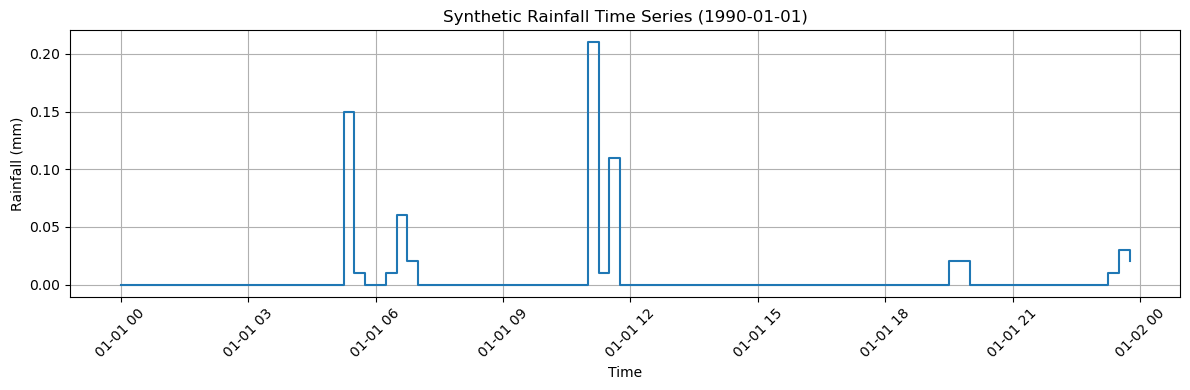

✅ SWMM .inp file updated with subcatchments and saved to: output_sewertris_3/sewer_model.inp


In [18]:
inp_file = os.path.join(output_folder, "sewer_model.inp")

# Time Series Generation
rainfall_data = SewerTris.generate_clustered_rainfall_timeseries(
    start_date="1990-01-01 00:00",
    end_date="1991-01-01 00:00",
    timestep_minutes=15,
    avg_annual_precip_mm=1200,
    wet_season_months=[4, 5, 6, 9, 10, 11],
    dry_wet_ratio=0.2,
    storm_prob=0.1,  # Probability of storm initiation per timestep
    storm_duration_range=(1, 6),  # Storm duration in number of timesteps (e.g., 1–5 hours)
    random_seed=42,
    preview_date="1990-01-01"
)

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

swmm.add_subcatchment_data_to_inp(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    subcatchments_path=subcatchments_path,
    raingage_id="1",
    raingage_coords=(500, 500),
    timeseries=rainfall_data,
    n_imperv=0.011, n_perv=0.15,
    s_imperv=0.0, s_perv=0.0,
    pct_zero=0, route_to="OUTLET", pct_routed="",
    infiltration_params=(90, 0.5, 7, "", ""),
    imperv_pct=5, width=100, slope=0.005, curblen=0
)


## 16. Model with WQ

In [19]:
inp_file = os.path.join(output_folder, "sewer_model.inp")

swmm.auto_add_pollutants_to_inp_fixed(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp")
)

inp_path = os.path.join(output_folder, "sewer_model.inp")

df = swmm.get_flow_components_from_node_pyswmm(
    inp_path=inp_path,
    link_id="P_OUTLET"
)


✅ Tagged inp written (uses CONCEN) -> output_sewertris_3/sewer_model.inp


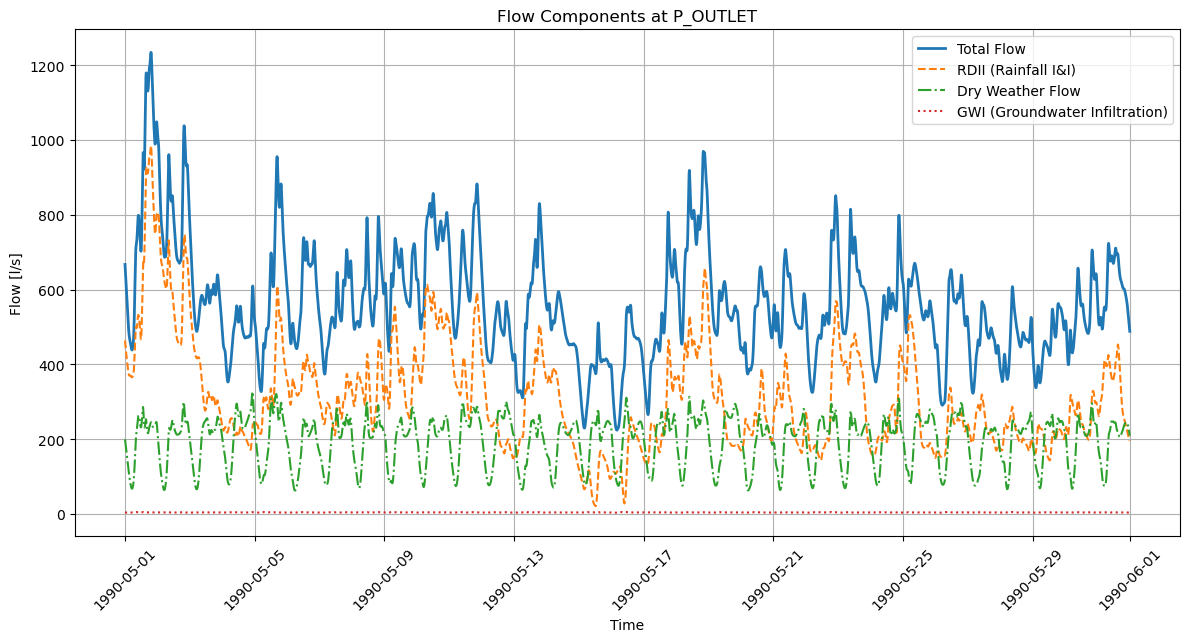

In [20]:

plots.plot_flow_components_v2(
    df,
    start="1990-05-01 00:00:00",
    end="1990-06-01 00:00:00"
)


In [21]:

# Set Datetime as index
df = df.set_index("Datetime")

# Convert DataFrame → Xarray Dataset
ds = df.to_xarray()

# Save to NetCDF
ds.to_netcdf(os.path.join(output_folder, "flows.nc"))
print("✅ Saved as flows.nc")


✅ Saved as flows.nc
